In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("https://raw.githubusercontent.com/Laxminarayen/InceptezGenAI-Batch26/refs/heads/main/27.%20Class%20Imbalance-F1Score-SMOTE/predictive_maintenance.csv")
print(df.shape)

(10000, 10)


In [3]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [4]:
df['Failure Type'].value_counts()

,count
Failure Type,
No Failure,9652
Heat Dissipation Failure,112
Power Failure,95
Overstrain Failure,78
Tool Wear Failure,45
Random Failures,18


In [5]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Target', 'Failure Type'],
      dtype='object')

In [6]:
df = df.drop(columns = ['UDI','Product ID'])

In [7]:
df.columns

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Target',
       'Failure Type'],
      dtype='object')

In [8]:
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,M,298.1,308.6,1551,42.8,0,0,No Failure
1,L,298.2,308.7,1408,46.3,3,0,No Failure
2,L,298.1,308.5,1498,49.4,5,0,No Failure
3,L,298.2,308.6,1433,39.5,7,0,No Failure
4,L,298.2,308.7,1408,40.0,9,0,No Failure


In [9]:
df['Target'].value_counts() #0-No failure | 1-failure

,count
Target,
0,9661
1,339


In [10]:
df['Failure Type'].value_counts() #No Failure = 0 (Optional preprocessing step drop mismatch rows..)

,count
Failure Type,
No Failure,9652
Heat Dissipation Failure,112
Power Failure,95
Overstrain Failure,78
Tool Wear Failure,45
Random Failures,18


In [11]:
df.loc[(df['Failure Type'] == 'No Failure') & (df['Target'] == 1)] #I ll drop only if part of major class

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
1437,H,298.8,309.9,1439,45.2,40,1,No Failure
2749,M,299.7,309.2,1685,28.9,179,1,No Failure
4044,M,301.9,310.9,1419,47.7,20,1,No Failure
4684,M,303.6,311.8,1421,44.8,101,1,No Failure
5536,M,302.3,311.8,1363,54.0,119,1,No Failure
5941,L,300.6,310.7,1438,48.5,78,1,No Failure
6478,L,300.5,309.8,1663,29.1,145,1,No Failure
8506,L,298.4,309.6,1710,27.3,163,1,No Failure
9015,L,297.2,308.1,1431,49.7,210,1,No Failure


In [12]:
mismatch = (((df['Target']==0) & (df['Failure Type'] != "No Failure")) | ((df['Target']==1) & (df['Failure Type'] == "No Failure")))

In [13]:
mismatch

,0
0,False
1,False
2,False
3,False
4,False
...,...
9995,False
9996,False
9997,False
9998,False


In [14]:
df = df[~mismatch].reset_index(drop=True)

In [15]:
df.shape

(9973, 8)

In [16]:
df['Failure Type'].value_counts()

,count
Failure Type,
No Failure,9643
Heat Dissipation Failure,112
Power Failure,95
Overstrain Failure,78
Tool Wear Failure,45


In [17]:
df = pd.get_dummies(df, columns = ['Type'], drop_first = True)
df.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,No Failure,False,True
1,298.2,308.7,1408,46.3,3,0,No Failure,True,False
2,298.1,308.5,1498,49.4,5,0,No Failure,True,False
3,298.2,308.6,1433,39.5,7,0,No Failure,True,False
4,298.2,308.7,1408,40.0,9,0,No Failure,True,False


In [18]:
# [yes, may, no]
# [1,   0,    0] - Category
# [1,   0]        -

# [0,   0,   1] - Rejected
# [0,   0]

# "Degrees of Freedom" #n-1 | 1

In [19]:
df.columns

Index(['Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Target',
       'Failure Type', 'Type_L', 'Type_M'],
      dtype='object')

In [20]:
from sklearn.model_selection import train_test_split

feature_cols = ['Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type_L', 'Type_M']

X = df[feature_cols]
y_binary = df['Target']
y_multi = df['Failure Type']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X,y_multi, test_size = 0.2, random_state = 24, stratify = y_multi)

In [22]:
y_train.value_counts()

,count
Failure Type,
No Failure,7714
Heat Dissipation Failure,90
Power Failure,76
Overstrain Failure,62
Tool Wear Failure,36


In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train),columns = feature_cols, index = X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test),columns = feature_cols, index = X_test.index)

In [24]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)
#results = []

def evaluate(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro')
    recall = recall_score(y_true, y_pred,'macro')
    f1 = f1_score(y_true, y_pred,'weighted')
    return [accuracy, precision, recall, f1]

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [26]:
results_multi_class = []

log_reg_m = LogisticRegression(random_state=24,max_iter=1000)
Knn_m = KNeighborsClassifier(n_neighbors = 5)
tree_m = DecisionTreeClassifier(random_state=24)

In [27]:
labels = sorted(y_multi.unique())

In [28]:
labels

['Heat Dissipation Failure',
 'No Failure',
 'Overstrain Failure',
 'Power Failure',
 'Tool Wear Failure']

In [29]:
for name, model in [('Logistic Regression', log_reg_m), ('KNN', Knn_m), ('Decision Tree', tree_m)]:
    model.fit(X_train_scaled, y_train)
    print(f"Model: {name}")
    y_pred = model.predict(X_test_scaled)
    #row = evaluate(y_test,y_pred)
    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test,y_pred),
        "Precision": precision_score(y_test,y_pred,average='macro'),
        "Recall": recall_score(y_test,y_pred, average='macro'),
        "F1 Score": f1_score(y_test,y_pred, average='weighted')
    }
    print(classification_report(y_test,y_pred,target_names=labels))
    results_multi_class.append(metrics)

Model: Logistic Regression
                          precision    recall  f1-score   support

Heat Dissipation Failure       0.88      0.32      0.47        22
              No Failure       0.98      1.00      0.99      1929
      Overstrain Failure       0.91      0.62      0.74        16
           Power Failure       0.83      0.79      0.81        19
       Tool Wear Failure       0.00      0.00      0.00         9

                accuracy                           0.98      1995
               macro avg       0.72      0.55      0.60      1995
            weighted avg       0.98      0.98      0.98      1995

Model: KNN
                          precision    recall  f1-score   support

Heat Dissipation Failure       0.40      0.09      0.15        22
              No Failure       0.97      1.00      0.98      1929
      Overstrain Failure       0.57      0.25      0.35        16
           Power Failure       0.60      0.16      0.25        19
       Tool Wear Failure       0.0

In [30]:
#Across all failure categories a balance of good predictions is achieved in Decision Tree model as compared a
#against other models.. and the support for this is given by the F1-score (harmonic mean) for individual classes

In [31]:
smallest_class_size = y_train.value_counts().min()
smallest_class_size

36

In [32]:
y_train.value_counts()

,count
Failure Type,
No Failure,7714
Heat Dissipation Failure,90
Power Failure,76
Overstrain Failure,62
Tool Wear Failure,36


In [33]:
safe_k = max(1, min(5, int(smallest_class_size-1)))

In [34]:
safe_k

5

In [35]:
!pip install imblearn

In [36]:
import imblearn

'minority': resample only the minority class;

'not minority': resample all classes but the minority class;

'not majority': resample all classes but the majority class;

'all': resample all classes;

'auto': equivalent to 'not majority'.

In [37]:
from  imblearn.over_sampling  import SMOTE

smote = SMOTE(random_state=24, k_neighbors = safe_k)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

In [38]:
y_train_sm.value_counts()

#No failure has to be passed so other categories no what is majority number

,count
Failure Type,
No Failure,7714
Heat Dissipation Failure,7714
Overstrain Failure,7714
Power Failure,7714
Tool Wear Failure,7714


In [39]:
for name, model in [('Logistic Regression', log_reg_m), ('KNN', Knn_m), ('Decision Tree', tree_m)]:
    model.fit(X_train_sm, y_train_sm) #Fitting on smote
    print(f"Model: {name}")
    y_pred = model.predict(X_test_scaled) #Test - real life simulation
    #row = evaluate(y_test,y_pred)
    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test,y_pred),
        "Precision": precision_score(y_test,y_pred,average='macro'),
        "Recall": recall_score(y_test,y_pred, average='macro'),
        "F1 Score": f1_score(y_test,y_pred, average='weighted')
    }
    print(classification_report(y_test,y_pred,target_names=labels))
    results_multi_class.append(metrics)

Model: Logistic Regression
                          precision    recall  f1-score   support

Heat Dissipation Failure       0.29      0.91      0.43        22
              No Failure       1.00      0.88      0.93      1929
      Overstrain Failure       0.42      0.94      0.58        16
           Power Failure       0.38      0.95      0.55        19
       Tool Wear Failure       0.04      0.67      0.08         9

                accuracy                           0.88      1995
               macro avg       0.42      0.87      0.51      1995
            weighted avg       0.97      0.88      0.92      1995

Model: KNN
                          precision    recall  f1-score   support

Heat Dissipation Failure       0.29      0.68      0.41        22
              No Failure       0.99      0.93      0.96      1929
      Overstrain Failure       0.42      0.88      0.57        16
           Power Failure       0.34      0.68      0.46        19
       Tool Wear Failure       0.0

In [40]:
#Hyper parameter tuning
#Feature Engineering

In [42]:
#sklearn.tree
from sklearn.ensemble import RandomForestClassifier

rf_m = RandomForestClassifier(n_estimators = 300, random_state=24)
rf_m.fit(X_train_scaled, y_train)
y_pred = rf_m.predict(X_test_scaled)

In [43]:
print(classification_report(y_test,y_pred,target_names=labels))

                          precision    recall  f1-score   support

Heat Dissipation Failure       1.00      0.55      0.71        22
              No Failure       0.99      1.00      0.99      1929
      Overstrain Failure       1.00      0.56      0.72        16
           Power Failure       0.79      0.79      0.79        19
       Tool Wear Failure       0.00      0.00      0.00         9

                accuracy                           0.98      1995
               macro avg       0.75      0.58      0.64      1995
            weighted avg       0.98      0.98      0.98      1995



In [80]:
#sklearn.tree
from sklearn.ensemble import RandomForestClassifier

rf_m = RandomForestClassifier(n_estimators = 500, random_state=24, oob_score = True)
rf_m.fit(X_train_sm, y_train_sm)
y_pred = rf_m.predict(X_test_scaled)

In [82]:
rf_m.oob_score_ #Accuracy on the OOB predictions aggregated from calculations of per tree oob scores

0.9954109411459684

In [47]:
print(classification_report(y_test,y_pred,target_names=labels))

                          precision    recall  f1-score   support

Heat Dissipation Failure       0.82      0.82      0.82        22
              No Failure       0.99      0.98      0.99      1929
      Overstrain Failure       0.57      0.81      0.67        16
           Power Failure       0.57      0.89      0.69        19
       Tool Wear Failure       0.14      0.33      0.19         9

                accuracy                           0.97      1995
               macro avg       0.62      0.77      0.67      1995
            weighted avg       0.98      0.97      0.97      1995



In [48]:
#XG-Boost, GBM are boosting algorithms not covered in our syllabus. RF, Adaboost, XGBoost, GBM are Hackathon winning algorithms.
# All Ensemble algorithms are hackathon winning algorithms as they are powerful

In [49]:
def rf_proximity_matrix(rf_model, X):  #Total number of trees in which the rows land in the same leaf
  """Fraction of trees in which each pair of rows land in the same leaf"""
  leaves = rf_model.apply(X)
  n_trees = leaves.shape[1]
  proximity = np.zeros((len(X),len(X)))
  for t in range(n_trees):
    tree_leaves = leaves[:,t]
    same_leaf = (tree_leaves[:,None] == tree_leaves[None,:])
    proximity += same_leaf
  proximity /= n_trees
  return proximity

In [50]:
rng = np.random.RandomState(24) #Randomness to select rows
y_test_arr = y_test.values
sample_positions = [] #new list

#------------------------- RANDOM POSITION CHOOSING -----------------------------------
for cls in labels:
  idx = np.where(y_test_arr == cls)[0] #For each class label
  take = idx if len(idx) <= 8 else rng.choice(idx, size=8, replace=False) #In random picking 8 rows
  sample_positions.append(take) #appending those 8 rows in a new list
sample_positions = np.concatenate(sample_positions) #all rows are concatinated as indices
#------------------------- RANDOM POSITION CHOOSING -----------------------------------

X_sample = X_test_scaled.values[sample_positions] #Subset of X-test based on sampled_indices we are picking X subset
y_sample = y_test.iloc[sample_positions] #same sample positions are also used for y label

#I am taking a subset for the purpose of visualization because I want to show heatmap

In [53]:
X_sample #X_test

array([[ 1.50851634,  0.81414677, -1.11300073,  1.11884896,  1.04363484,
         0.81347227, -0.65457552],
       [ 1.15781863,  0.61132614, -0.9113115 ,  0.69464565,  0.91827995,
         0.81347227, -0.65457552],
       [ 1.10771896,  0.40850552, -1.07378338,  0.85624691,  0.83993314,
         0.81347227, -0.65457552],
       [ 0.8572206 ,  0.13807802, -1.16902552,  2.149057  , -0.94637402,
         0.81347227, -0.65457552],
       [ 1.05761929,  0.47611239, -1.37631723,  2.27025795, -0.10022852,
        -1.2292982 , -0.65457552],
       [ 1.65881536,  0.88175364, -1.06257842,  0.82594667, -1.18141444,
         0.81347227, -0.65457552],
       [ 1.35821732,  0.74653989, -1.3595098 ,  2.09855661,  0.27583614,
        -1.2292982 ,  1.5277076 ],
       [ 1.30811765,  0.67893302, -1.18023048,  0.87644707,  0.05646509,
        -1.2292982 ,  1.5277076 ],
       [-1.59766336, -1.21405948,  0.57894785, -0.5274639 ,  1.31001397,
         0.81347227, -0.65457552],
       [-1.29706533, -1.0788

In [ ]:
y_sample #Y_test

In [54]:
leaves = rf_m.apply(X_sample) #X_test_scaled itself can also go inside

In [55]:
leaves

array([[ 239, 1008,  360, ...,  411,  486,  312],
       [ 186,  977,  404, ...,  395,  489,  329],
       [ 186,  977,  374, ...,  395,  486,  305],
       ...,
       [ 464,  122,  584, ...,  603,  678,  986],
       [ 707,  395,  930, ...,  882, 1146,  856],
       [ 494,  290,  569, ...,   89,  795,  447]])

In [56]:
leaves.shape #8 rows in random for each class - 5 classes each - 40 rows.. ID of leaf in 500 trees

(40, 500)

In [57]:
n_tress = leaves.shape[1]

In [70]:
proximity = np.zeros((len(X_sample),len(X_sample)))

In [60]:
proximity.shape

(40, 40)

In [64]:
leaves.shape

(40, 500)

In [66]:
tree_leaves[:,None].shape

(40, 1)

In [67]:
tree_leaves[None,:].shape

(1, 40)

In [71]:
for t in range(n_tress):
  tree_leaves = leaves[:,t] #I am going inside each tree and tree_leaves variable will now hold leaf ID per row
  #print(tree_leaves)
  same_leaf = (tree_leaves[:,None] == tree_leaves[None,:]) #For every tree what are the rows that end up in same leaf
  proximity+=same_leaf #Global all tree counter of proximities

In [74]:
proximity = proximity/ n_tress

In [78]:
same_leaf #Per tree local comparison

array([[ True, False, False, ..., False, False, False],
       [False,  True, False, ..., False, False, False],
       [False, False,  True, ..., False, False, False],
       ...,
       [False, False, False, ...,  True, False, False],
       [False, False, False, ..., False,  True, False],
       [False, False, False, ..., False, False,  True]])

In [75]:
proximity

array([[1.   , 0.018, 0.034, ..., 0.   , 0.   , 0.   ],
       [0.018, 1.   , 0.162, ..., 0.   , 0.   , 0.   ],
       [0.034, 0.162, 1.   , ..., 0.   , 0.   , 0.   ],
       ...,
       [0.   , 0.   , 0.   , ..., 1.   , 0.   , 0.   ],
       [0.   , 0.   , 0.   , ..., 0.   , 1.   , 0.018],
       [0.   , 0.   , 0.   , ..., 0.   , 0.018, 1.   ]])

<Axes: >

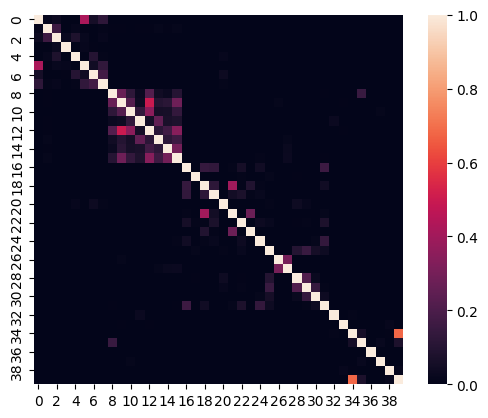

In [77]:
sns.heatmap(proximity,vmin=0, vmax =1, square = True)

In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier

# 1. Train your random forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 2. Get the leaf node IDs for each sample across all trees
# Shape of leaf_ids will be (n_samples, n_estimators)
leaf_ids = rf.apply(X_train)

# 3. Compute the proximity matrix
# We compare every sample's leaf IDs with every other sample's leaf IDs
# Using broadcasting yields a boolean matrix of shape (n_samples, n_samples, n_estimators)
same_leaf = leaf_ids[:, np.newaxis, :] == leaf_ids[np.newaxis, :, :]

# Sum across the trees and divide by total trees to get percentages
proximity_matrix = np.sum(same_leaf, axis=2) / rf.n_estimators

In [83]:
import joblib
import json

joblib.dump(scaler, 'scaler.joblib')
joblib.dump(rf_m, 'rf_model.joblib')

['rf_model.joblib']

In [86]:
feature_stats = {
    col: {
        'min': float(X[col].min()),
        'max': float(X[col].max()),
        'mean': float(X[col].mean()),
        'std': float(X[col].std())
    }
    for col in X.columns
} #dict comprehension - just like list comprehension

In [87]:
feature_cols

['Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]',
 'Type_L',
 'Type_M']

In [91]:
print("Hello I am front End") #PYTHON COMPILER / ENGINE

Hello I am front


In [88]:
metadata_rfs = {
    'feature_cols': feature_cols,
    "raw_numeric_cols": ['Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]'],
    'type_categories':['H','L','M'],
    'feature_stats': feature_stats,
    'multiclass_labels': labels,
    'n_trees': rf_m.n_estimators,
    'max_depth': rf_m.max_depth,
}

In [90]:
json.dump(metadata_rfs, open('metadata_rfs.json','w'))

In [ ]:
#       Input -----> (MODEL) FROZEN -----> Numbers
#1. Web Application..

#    USER -> look at Front (User Interface (UI)) input via Text box ->
#    Taken back to my RF model (BACKEND SERVER / ENGINE) Which processes predictions via RF
#    Gives it back to the front end


#    NEW DATA -> FROZEN MODEL -> Predictions (NO MODEL UPDATE!!!!!!)

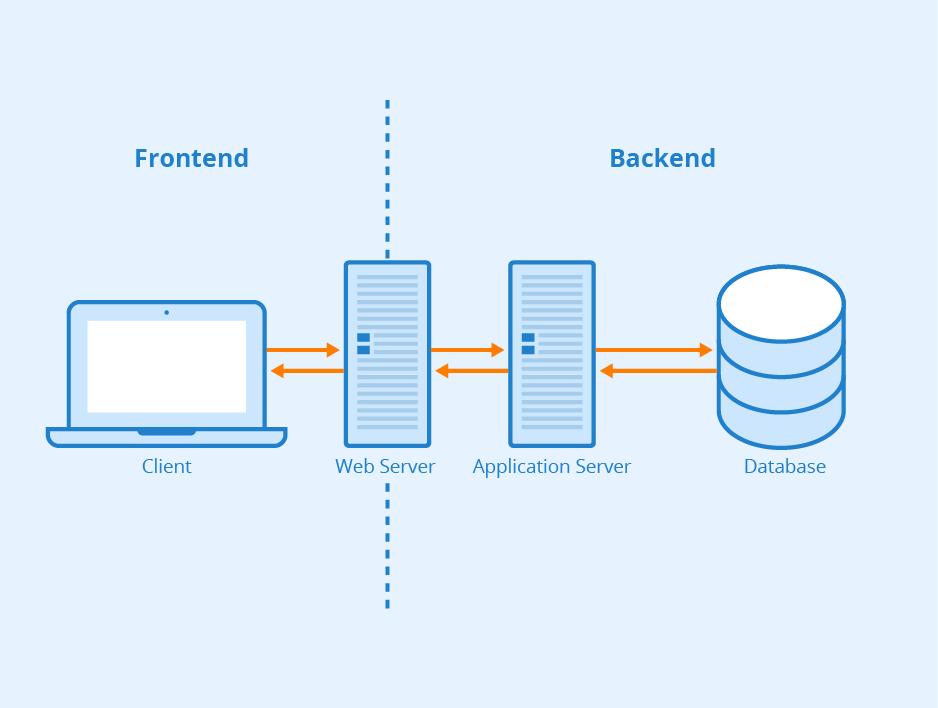

In [ ]:
#Model serialization / packaging
#Deploying in Streamlit
#Break till 10:20am IST